In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import power_transform
from scipy.stats import norm

# **Function 4** — Optimal Warehouse Product Placement

Optimising four hyperparameters of an ML model that approximates warehouse placement decisions. Output reflects improvement over an expensive baseline.

- **Optimisation Goal:** Maximise
- **Input:** 4D

Loading the cumulative dataset and appending the Week 7 result.

In [2]:
# Load current cumulative dataset (original + prior weekly updates) for Function 4
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_4/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_4/initial_outputs.npy')

# New data for Week 9 (Function 4)
X_w8_new_point = np.array([0.348650, 0.393784, 0.359305, 0.401263], dtype=np.float64)
Y_w8_new_point = np.array([0.5014641372932798], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w8_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w8_new_point)
Y_updated = Y_all[unique_indices]

# Save updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_4/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_4/initial_outputs.npy', Y_updated)

# Print arrays
print("Updated Inputs (X) - Function 4: ", X_unique)
print("Updated Outputs (Y) - Function 4: ", Y_updated)

Updated Inputs (X) - Function 4:  [[0.03782483 0.66485335 0.16198218 0.25392378]
 [0.11245    0.456812   0.901233   0.005678  ]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.17034731 0.75695908 0.27652049 0.5312315 ]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.28213837 0.50598691 0.53053084 0.09630162]
 [0.32607578 0.4723669  0.453192   0.10588734]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.34865    0.393784   0.359305   0.401263  ]
 [0.387195   0.490423   0.43071    0.405493  ]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.402567   0.361014   0.353681   0.347064  ]
 [0.428988   0.443109   0.30979    0.428981  ]
 [0.434904   0.399307   0.463215   0.450952  ]
 [0.435024   0.412464   0.436414   0.423453  ]
 [0.464323   0.31525    0.

## **Output Analysis**

- **Comparison**: Week 8 returned 0.501, which is a solid recovery after the Week 7 regression. 
    - However, it still sits below the all-time best of 0.602 achieved in Week 6 at [0.403, 0.361, 0.354, 0.347].

- **Real-World Implications**: In warehouse product placement, the goal is to maximize efficiency over a baseline. 
    - My W8 result shows we are back in a high-performing configuration, but I haven't quite recaptured the perfect layout found two weeks ago.
    
- **Model Clues**: The decision to increase $\beta$ to 3.0 in Week 8 was correct—it prevented the model from getting stuck. 
    - The current data shows a clear cluster of success in the 0.34–0.40 range across all four dimensions. 
    - The model is now confident about the general area but needs more precision to hit the absolute peak.

## **Bayesian Optimisation**
- **Model**: Gaussian Process Regressor with Matern (nu=2.5) + WhiteKernel and Yeo-Johnson output transformation.

- **Reasoning**: The 4D space is complex, and the Matern kernel helps the model understand the spatial correlations between warehouse zones. 
    - The Yeo-Johnson transformation is used to linearize the output scores, making the "peak" easier for the GP to identify.

- **Changes for Week 9**: We are maintaining the kernel and transformation settings from Week 8, as they successfully pulled the performance back into the positive range.

- **Intended Impact**: To provide a stable estimation of where the 0.600+ threshold lives, allowing the acquisition function to narrow down the exact coordinates.

In [3]:
Y_transformed = power_transform(Y_updated.reshape(-1, 1), method='yeo-johnson').ravel()

# 3. Fit Model
kernel = Matern(nu=2.5) + WhiteKernel(noise_level=1e-5)
model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20)

model.fit(X_unique, Y_transformed)

,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",Matern(length...e_level=1e-05)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",20
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

## **Acquisition Function**: UCB with Increased Precision

- **Strategy**: Upper Confidence Bound (UCB) with $\beta=3.0$.

- **Reasoning**: A $\beta$ of 3.0 provides a healthy balance. 
    - It explores enough to ensure we aren't trapped in a local sub-peak, but it is focused enough to stay within the high-performing Warehouse Zone we've identified.
    
- **Key Changes**: We are narrowing the candidate grid. Instead of a wide search, we use a standard deviation of 0.015 (down from 0.02) centered on the Week 6 best. 
    - I am also shifting the focused/uniform split to 90/10 to maximize local refinement.

In [4]:
def upper_confidence_bound(X, model, beta=3.0):
    mu, sigma = model.predict(X, return_std=True)
    return mu + beta * sigma

# Focused Grid centered on W6 Best [0.403, 0.361, 0.354, 0.347]
w6_best = np.array([0.403, 0.361, 0.354, 0.347])
x_focused = np.random.normal(loc=w6_best, scale=0.015, size=(9000, 4))
x_uniform = np.random.uniform(0, 1, size=(1000, 4))
x_grid = np.vstack([x_focused, x_uniform])
x_grid = np.clip(x_grid, 0, 1)

# 6. Selection
ucb_values = upper_confidence_bound(x_grid, model, beta=3.0)
next_query = x_grid[np.argmax(ucb_values)]

print(f"Next Query Point (F4): {next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}")

Next Query Point (F4): 0.385448-0.399705-0.352187-0.382073


## **Visualisation**

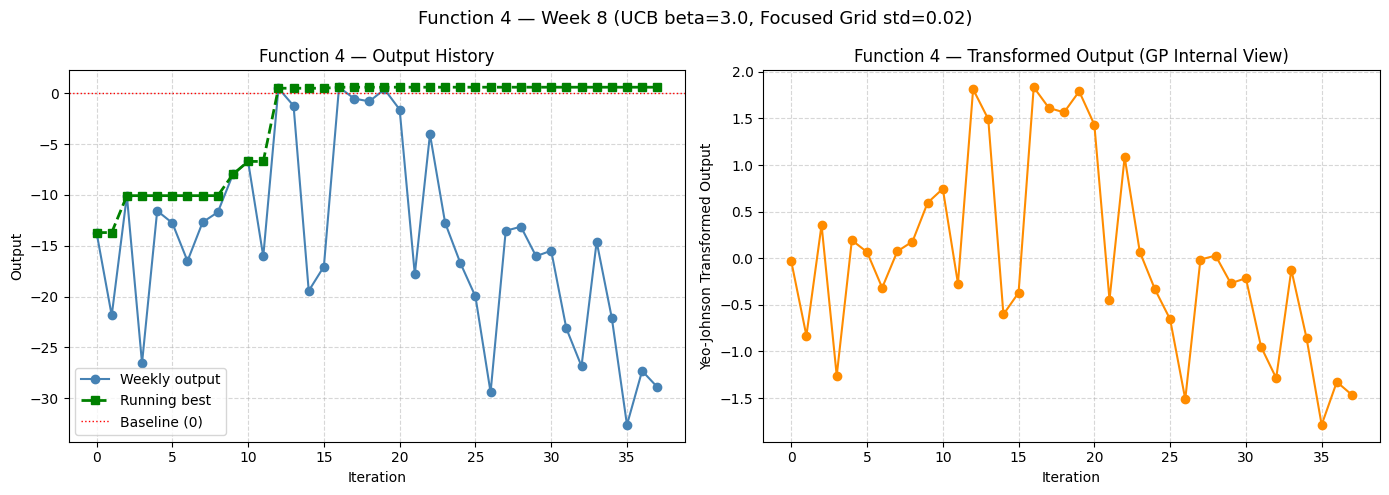

In [5]:
running_max = np.maximum.accumulate(Y_updated)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(Y_updated, marker='o', color='steelblue', linewidth=1.5, label='Weekly output')
axes[0].plot(running_max, marker='s', color='green', linewidth=2, linestyle='--', label='Running best')
axes[0].axhline(0, color='red', linestyle=':', linewidth=1, label='Baseline (0)')
axes[0].set_title('Function 4 — Output History')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Output')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Transformed Y to show GP's internal view
axes[1].plot(Y_transformed, marker='o', color='darkorange', linewidth=1.5)
axes[1].set_title('Function 4 — Transformed Output (GP Internal View)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Yeo-Johnson Transformed Output')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Function 4 — Week 8 (UCB beta=3.0, Focused Grid std=0.02)', fontsize=13)
plt.tight_layout()
plt.show()